# Sentiment Analysis - Exploratory Data Analysis

## Purpose
This notebook performs comprehensive EDA for customer sentiment analysis using HuggingFace Transformers model:
- **Model**: `distilbert-base-uncased-finetuned-sst-2-english`
- **Input**: Text data from emails, support tickets, call transcripts, survey responses
- **Output**: 
  - `sentiment_score` (-1.0 to 1.0) - Numeric sentiment score
  - `sentiment_category` - "very_negative", "negative", "neutral", "positive", "very_positive"
  - `keywords` - Extracted keywords indicating sentiment

## Sentiment Mapping Logic
- Score > 0.3 → "positive"
- Score -0.3 to 0.3 → "neutral"
- Score < -0.3 → "negative"

## Update Frequency
Every 24 hours for all accounts

## Key Analysis Areas
- Existing sentiment score distribution
- Sentiment category distribution
- Relationship between sentiment and other metrics (health_score, churn_probability, etc.)
- Industry and company size sentiment patterns
- Temporal sentiment trends

In [1]:
# Install required packages
%pip install pandas numpy matplotlib seaborn openpyxl transformers torch scikit-learn nltk

Note: you may need to restart the kernel to use updated packages.


d:\Internship\Renewal-Upsell-Advisor\Research\.venv\Scripts\python.exe: No module named pip


In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime, timedelta
import warnings
import json

warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 10

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load and Explore Data

In [3]:
# Load the dataset
# Try multiple possible paths
possible_paths = [
    Path("../../customer_data_25000.xlsx"),
    Path("../customer_data_25000.xlsx"),
    Path("customer_data_25000.xlsx"),
    Path("D:/Internship/Renewal-Upsell-Advisor/Research/customer_data_25000.xlsx")
]

data_path = None
for path in possible_paths:
    if path.exists():
        data_path = path
        break

if data_path is None:
    raise FileNotFoundError("Could not find customer_data_25000.xlsx. Please check the file path.")

df = pd.read_excel(data_path, sheet_name="Accounts")

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumn Names:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

print(f"\nFirst few rows:")
df.head()

Dataset loaded successfully!
Shape: 24,874 rows × 27 columns

Column Names:
   1. name
   2. domain
   3. industry
   4. company_size
   5. arr
   6. mrr
   7. contract_start_date
   8. contract_end_date
   9. renewal_date
  10. last_contact_date
  11. status
  12. renewal_stage
  13. health_score
  14. risk_score
  15. relationship_score
  16. churn_probability
  17. sentiment_score
  18. sentiment_category
  19. licenses_total
  20. licenses_used
  21. utilization_percentage
  22. csm_name
  23. csm_email
  24. primary_contact_name
  25. primary_contact_email
  26. primary_contact_phone
  27. salesforce_id

First few rows:


,name,domain,industry,company_size,arr,mrr,contract_start_date,contract_end_date,renewal_date,last_contact_date,...,sentiment_category,licenses_total,licenses_used,utilization_percentage,csm_name,csm_email,primary_contact_name,primary_contact_email,primary_contact_phone,salesforce_id
0,Cole LLC,colellc.com,Technology,Small,156049,13004.08,2025-06-05,2026-06-05,2026-06-05,2026-02-13 16:43:27,...,neutral,20,15,79,Sarah Chen,sarah.chen@company.com,Danielle Johnson,john21@example.net,001-581-896-0013x3890,NaN
1,"Stevens, Martinez and Nielsen",stevensmartinezandnielsen.com,Healthcare,Medium,517493,43124.42,2025-05-19,2026-05-19,2026-05-19,2026-02-04 16:43:27,...,positive,30,23,79,Maria Lopez,maria.lopez@company.com,Lisa Smith,helenpeterson@example.org,651.216.1559,NaN
2,Clark-Adams,clark-adams.com,Analytics,Large,64898,5408.17,2025-04-28,2026-04-28,2026-04-28,2026-02-12 16:43:27,...,negative,20,14,73,Emily Rodriguez,emily.rodriguez@company.com,Christian Carter,barbara10@example.net,441.731.6475,SF-748564
3,"Porter, Wilkerson and Day",porterwilkersonandday.com,Healthcare,Medium,43003,3583.58,2025-05-01,2026-05-01,2026-05-01,2026-02-06 16:43:27,...,neutral,20,14,73,David Kim,david.kim@company.com,Sharon Wong,amandasanchez@example.com,(748)535-0305x6413,SF-319684
4,Carlson-Mcdonald,carlson-mcdonald.com,Enterprise,Medium,100005,8333.75,2025-06-09,2026-06-09,2026-06-09,2026-01-19 16:43:27,...,very_positive,50,33,66,Sarah Chen,sarah.chen@company.com,Douglas Taylor,julie69@example.com,(332)887-1012x269,SF-944151


## 2. Analyze Existing Sentiment Data

In [4]:
# Check sentiment-related columns
print("=" * 80)
print("SENTIMENT DATA AVAILABILITY")
print("=" * 80)

if 'sentiment_score' in df.columns:
    print("✓ sentiment_score: Available")
    print(f"\nSentiment Score Statistics:")
    print(df['sentiment_score'].describe())
    print(f"\nMissing values: {df['sentiment_score'].isna().sum()} ({df['sentiment_score'].isna().sum()/len(df)*100:.2f}%)")
else:
    print("✗ sentiment_score: Missing")

if 'sentiment_category' in df.columns:
    print("\n✓ sentiment_category: Available")
    print(f"\nSentiment Category Distribution:")
    print(df['sentiment_category'].value_counts())
    print(f"\nMissing values: {df['sentiment_category'].isna().sum()} ({df['sentiment_category'].isna().sum()/len(df)*100:.2f}%)")
else:
    print("\n✗ sentiment_category: Missing")

SENTIMENT DATA AVAILABILITY
✓ sentiment_score: Available

Sentiment Score Statistics:
count    24874.000000
mean         0.390492
std          0.438628
min         -0.999400
25%          0.098725
50%          0.477550
75%          0.738200
max          0.999900
Name: sentiment_score, dtype: float64

Missing values: 0 (0.00%)

✓ sentiment_category: Available

Sentiment Category Distribution:
sentiment_category
neutral          8770
positive         7126
very_positive    7097
negative          942
very_negative     939
Name: count, dtype: int64

Missing values: 0 (0.00%)


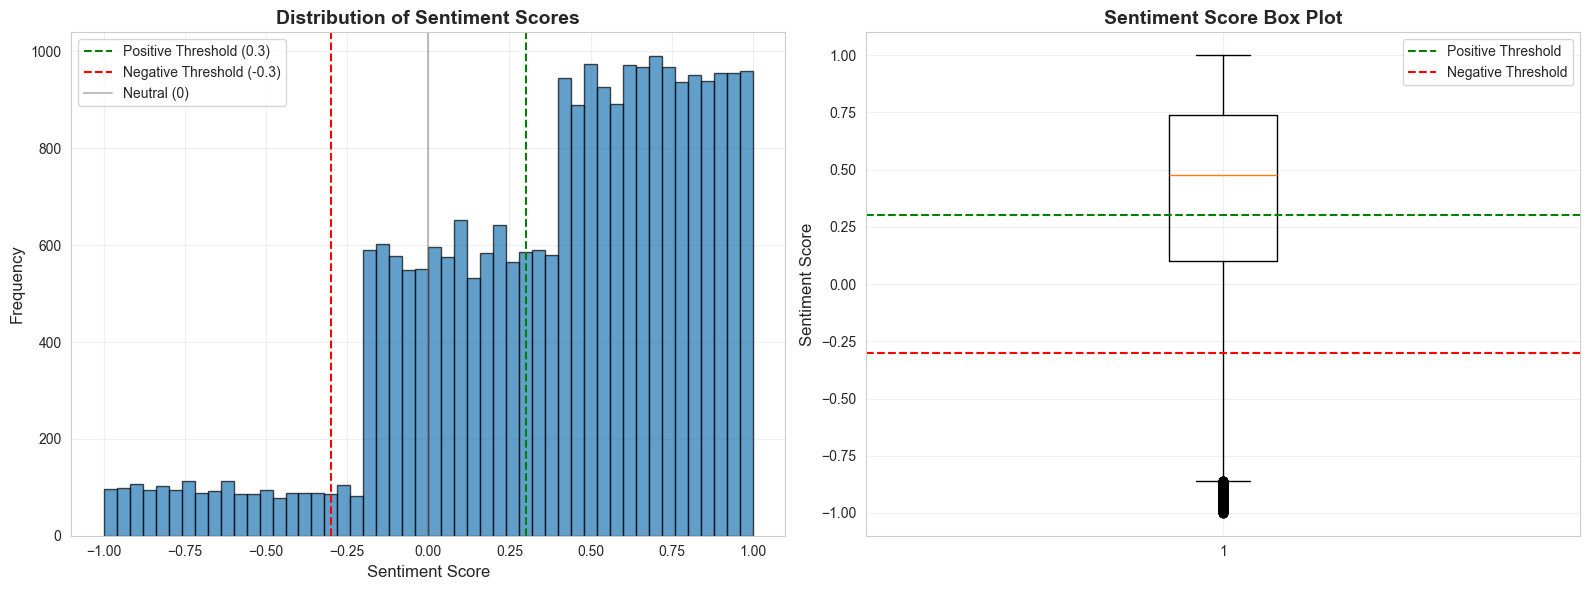

In [5]:
# Visualize sentiment score distribution
if 'sentiment_score' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Histogram
    axes[0].hist(df['sentiment_score'].dropna(), bins=50, edgecolor='black', alpha=0.7)
    axes[0].axvline(x=0.3, color='green', linestyle='--', label='Positive Threshold (0.3)')
    axes[0].axvline(x=-0.3, color='red', linestyle='--', label='Negative Threshold (-0.3)')
    axes[0].axvline(x=0, color='gray', linestyle='-', alpha=0.5, label='Neutral (0)')
    axes[0].set_xlabel('Sentiment Score', fontsize=12)
    axes[0].set_ylabel('Frequency', fontsize=12)
    axes[0].set_title('Distribution of Sentiment Scores', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Box plot
    axes[1].boxplot(df['sentiment_score'].dropna(), vert=True)
    axes[1].axhline(y=0.3, color='green', linestyle='--', label='Positive Threshold')
    axes[1].axhline(y=-0.3, color='red', linestyle='--', label='Negative Threshold')
    axes[1].set_ylabel('Sentiment Score', fontsize=12)
    axes[1].set_title('Sentiment Score Box Plot', fontsize=14, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

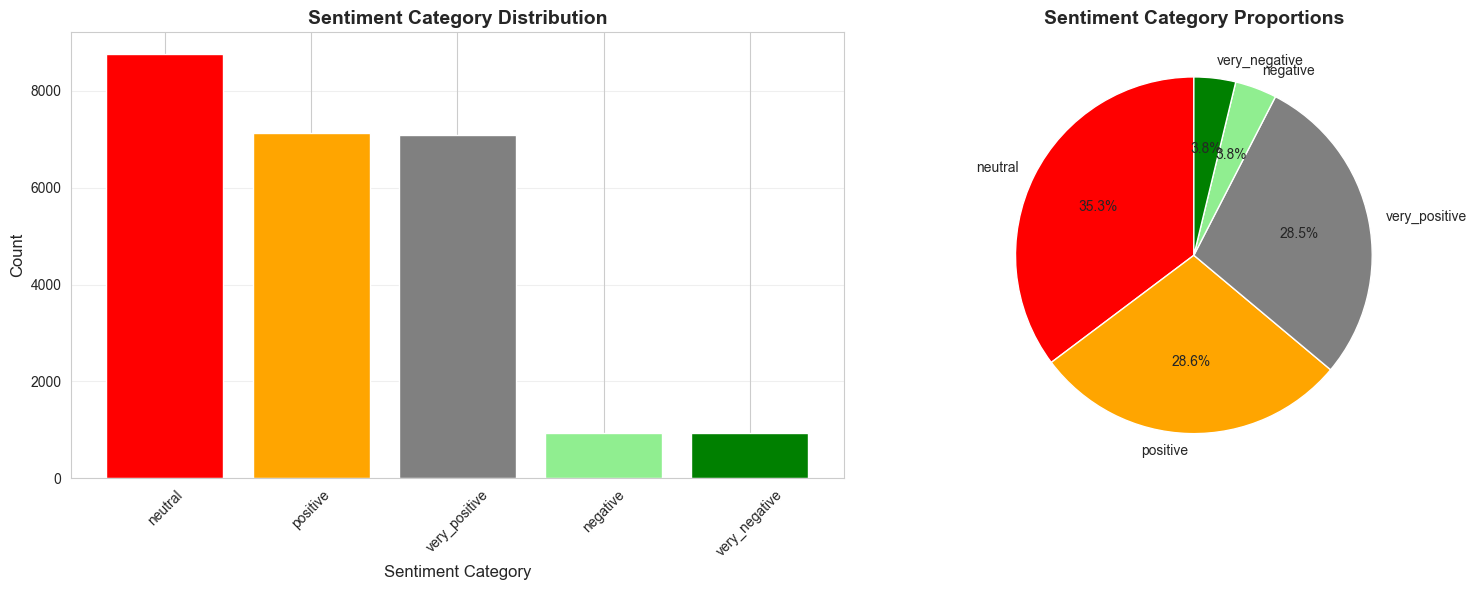


Sentiment Category Percentages:
  neutral: 8770 (35.26%)
  positive: 7126 (28.65%)
  very_positive: 7097 (28.53%)
  negative: 942 (3.79%)
  very_negative: 939 (3.78%)


In [7]:
# Visualize sentiment category distribution
if 'sentiment_category' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Count plot
    category_counts = df['sentiment_category'].value_counts()
    axes[0].bar(category_counts.index, category_counts.values, color=['red', 'orange', 'gray', 'lightgreen', 'green'])
    axes[0].set_xlabel('Sentiment Category', fontsize=12)
    axes[0].set_ylabel('Count', fontsize=12)
    axes[0].set_title('Sentiment Category Distribution', fontsize=14, fontweight='bold')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(True, alpha=0.3, axis='y')
    
    # Pie chart
    axes[1].pie(category_counts.values, labels=category_counts.index, autopct='%1.1f%%', 
                colors=['red', 'orange', 'gray', 'lightgreen', 'green'], startangle=90)
    axes[1].set_title('Sentiment Category Proportions', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nSentiment Category Percentages:")
    for cat, count in category_counts.items():
        print(f"  {cat}: {count} ({count/len(df)*100:.2f}%)")

## 3. Sentiment vs Other Metrics Analysis

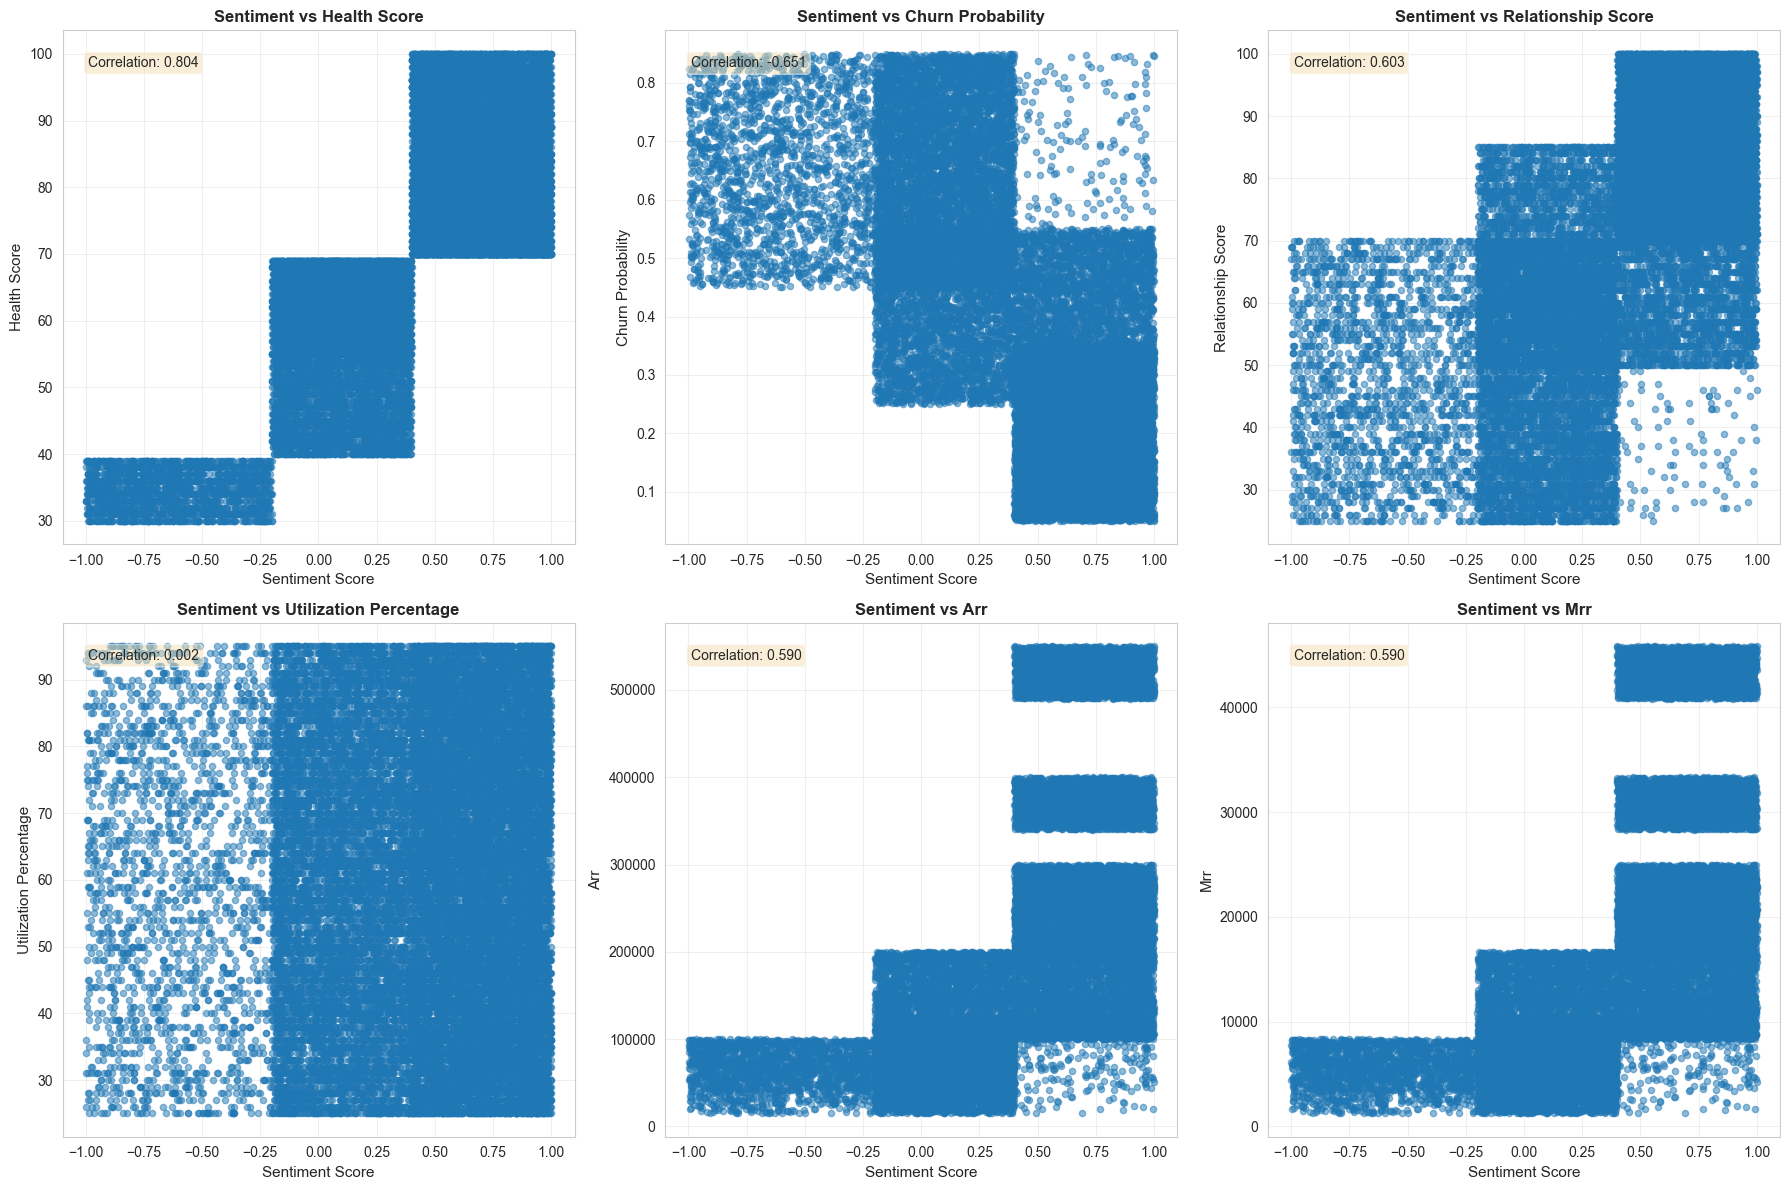


CORRELATION MATRIX: Sentiment Score vs Other Metrics
sentiment_score           1.000000
health_score              0.804332
relationship_score        0.603144
arr                       0.590039
mrr                       0.590039
utilization_percentage    0.002152
churn_probability        -0.651479
Name: sentiment_score, dtype: float64


In [8]:
# Analyze relationship between sentiment and other key metrics
if 'sentiment_score' in df.columns:
    metrics_to_analyze = ['health_score', 'churn_probability', 'relationship_score', 
                          'utilization_percentage', 'arr', 'mrr']
    
    available_metrics = [m for m in metrics_to_analyze if m in df.columns]
    
    if available_metrics:
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        axes = axes.flatten()
        
        for idx, metric in enumerate(available_metrics[:6]):
            if idx < len(axes):
                # Scatter plot
                axes[idx].scatter(df['sentiment_score'], df[metric], alpha=0.5, s=20)
                axes[idx].set_xlabel('Sentiment Score', fontsize=11)
                axes[idx].set_ylabel(metric.replace('_', ' ').title(), fontsize=11)
                axes[idx].set_title(f'Sentiment vs {metric.replace("_", " ").title()}', 
                                   fontsize=12, fontweight='bold')
                axes[idx].grid(True, alpha=0.3)
                
                # Calculate correlation
                corr = df[['sentiment_score', metric]].corr().iloc[0, 1]
                axes[idx].text(0.05, 0.95, f'Correlation: {corr:.3f}', 
                              transform=axes[idx].transAxes, 
                              bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
                              fontsize=10, verticalalignment='top')
        
        # Hide unused subplots
        for idx in range(len(available_metrics), len(axes)):
            axes[idx].axis('off')
        
        plt.tight_layout()
        plt.show()
        
        # Print correlation matrix
        print("\n" + "=" * 80)
        print("CORRELATION MATRIX: Sentiment Score vs Other Metrics")
        print("=" * 80)
        corr_df = df[['sentiment_score'] + available_metrics].corr()
        print(corr_df['sentiment_score'].sort_values(ascending=False))

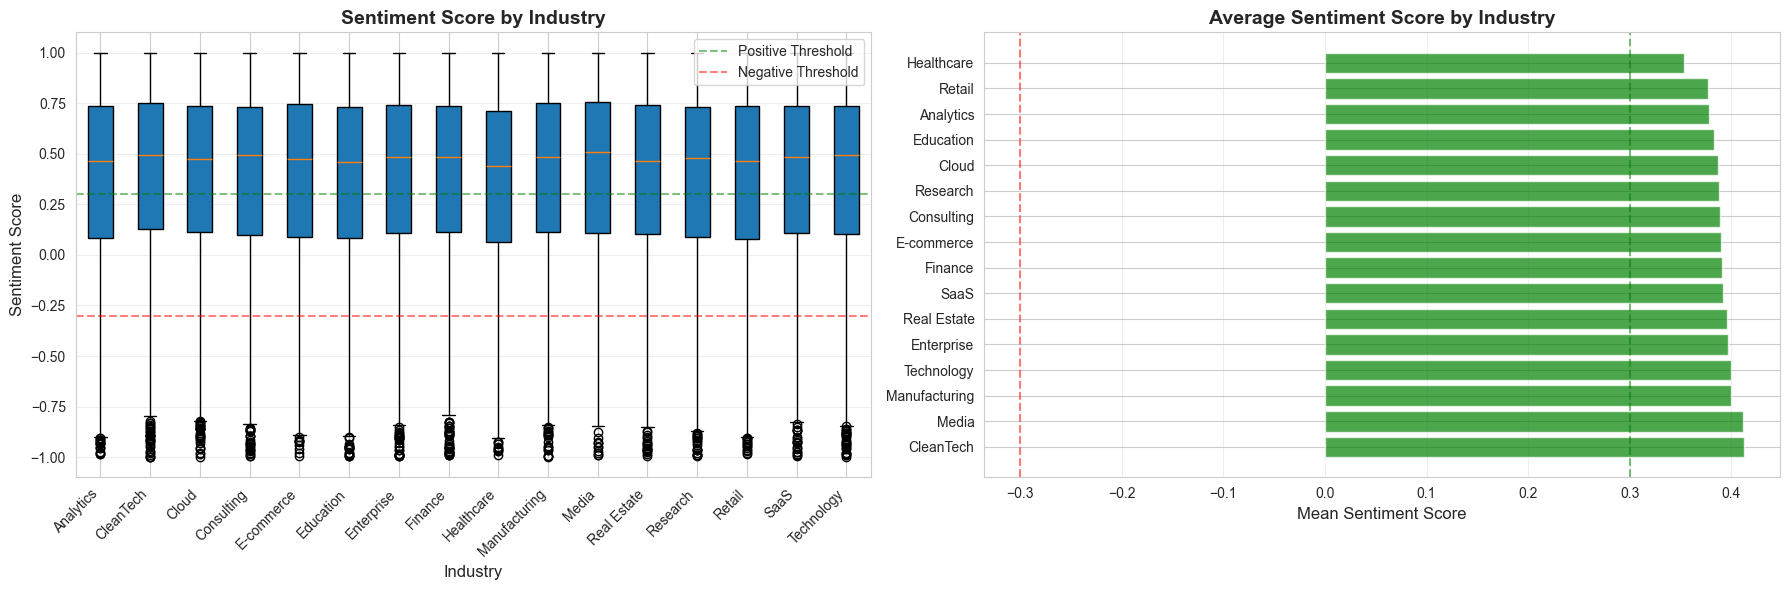


Mean Sentiment Score by Industry:
industry
CleanTech        0.412526
Media            0.411469
Manufacturing    0.400372
Technology       0.399837
Enterprise       0.397356
Real Estate      0.395579
SaaS             0.392436
Finance          0.390762
E-commerce       0.389909
Consulting       0.389097
Research         0.388133
Cloud            0.387455
Education        0.383503
Analytics        0.378368
Retail           0.377252
Healthcare       0.353653
Name: sentiment_score, dtype: float64


In [10]:
# Analyze sentiment by industry
if 'sentiment_score' in df.columns and 'industry' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    # Box plot by industry
    industry_sentiment = df.groupby('industry')['sentiment_score'].apply(list)
    industries = industry_sentiment.index.tolist()
    data_to_plot = [industry_sentiment.values]
    
    bp = axes[0].boxplot([df[df['industry'] == ind]['sentiment_score'].dropna() 
                          for ind in industries], labels=industries, patch_artist=True)
    axes[0].axhline(y=0.3, color='green', linestyle='--', alpha=0.5, label='Positive Threshold')
    axes[0].axhline(y=-0.3, color='red', linestyle='--', alpha=0.5, label='Negative Threshold')
    axes[0].set_ylabel('Sentiment Score', fontsize=12)
    axes[0].set_xlabel('Industry', fontsize=12)
    axes[0].set_title('Sentiment Score by Industry', fontsize=14, fontweight='bold')
    axes[0].tick_params(axis='x', rotation=45)
    plt.setp(axes[0].xaxis.get_majorticklabels(), ha='right')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3, axis='y')
    
    # Bar plot - mean sentiment by industry
    industry_mean = df.groupby('industry')['sentiment_score'].mean().sort_values(ascending=False)
    colors = ['green' if x > 0.3 else 'red' if x < -0.3 else 'gray' for x in industry_mean.values]
    axes[1].barh(industry_mean.index, industry_mean.values, color=colors, alpha=0.7)
    axes[1].axvline(x=0.3, color='green', linestyle='--', alpha=0.5)
    axes[1].axvline(x=-0.3, color='red', linestyle='--', alpha=0.5)
    axes[1].set_xlabel('Mean Sentiment Score', fontsize=12)
    axes[1].set_title('Average Sentiment Score by Industry', fontsize=14, fontweight='bold')
    axes[1].grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.show()
    
    print("\nMean Sentiment Score by Industry:")
    print(industry_mean)

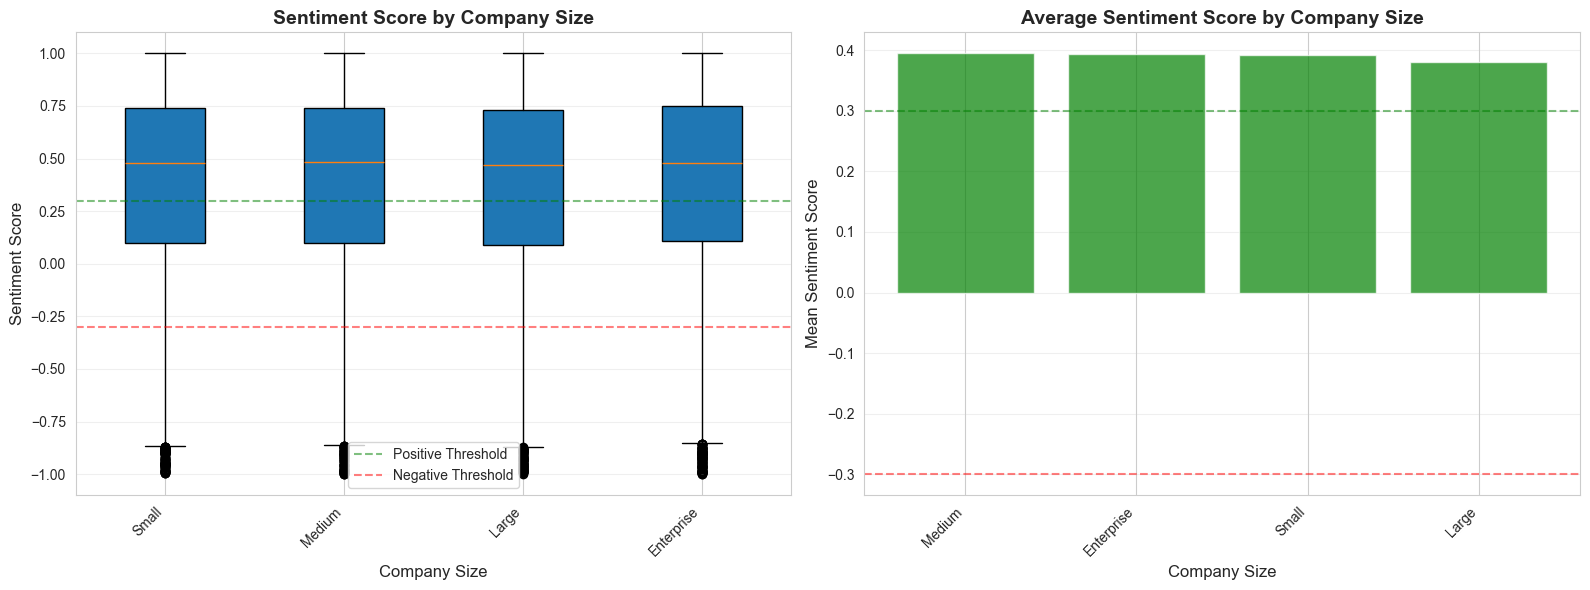


Mean Sentiment Score by Company Size:
company_size
Medium        0.395175
Enterprise    0.393808
Small         0.391930
Large         0.381175
Name: sentiment_score, dtype: float64


In [11]:
# Analyze sentiment by company size
if 'sentiment_score' in df.columns and 'company_size' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Box plot by company size
    company_sizes = df['company_size'].dropna().unique()
    bp = axes[0].boxplot([df[df['company_size'] == size]['sentiment_score'].dropna() 
                         for size in company_sizes], labels=company_sizes, patch_artist=True)
    axes[0].axhline(y=0.3, color='green', linestyle='--', alpha=0.5, label='Positive Threshold')
    axes[0].axhline(y=-0.3, color='red', linestyle='--', alpha=0.5, label='Negative Threshold')
    axes[0].set_ylabel('Sentiment Score', fontsize=12)
    axes[0].set_xlabel('Company Size', fontsize=12)
    axes[0].set_title('Sentiment Score by Company Size', fontsize=14, fontweight='bold')
    axes[0].tick_params(axis='x', rotation=45)
    plt.setp(axes[0].xaxis.get_majorticklabels(), ha='right')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3, axis='y')
    
    # Bar plot - mean sentiment by company size
    size_mean = df.groupby('company_size')['sentiment_score'].mean().sort_values(ascending=False)
    colors = ['green' if x > 0.3 else 'red' if x < -0.3 else 'gray' for x in size_mean.values]
    axes[1].bar(size_mean.index, size_mean.values, color=colors, alpha=0.7)
    axes[1].axhline(y=0.3, color='green', linestyle='--', alpha=0.5)
    axes[1].axhline(y=-0.3, color='red', linestyle='--', alpha=0.5)
    axes[1].set_ylabel('Mean Sentiment Score', fontsize=12)
    axes[1].set_xlabel('Company Size', fontsize=12)
    axes[1].set_title('Average Sentiment Score by Company Size', fontsize=14, fontweight='bold')
    axes[1].tick_params(axis='x', rotation=45)
    plt.setp(axes[1].xaxis.get_majorticklabels(), ha='right')
    axes[1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    print("\nMean Sentiment Score by Company Size:")
    print(size_mean)

## 5. Temporal Sentiment Analysis

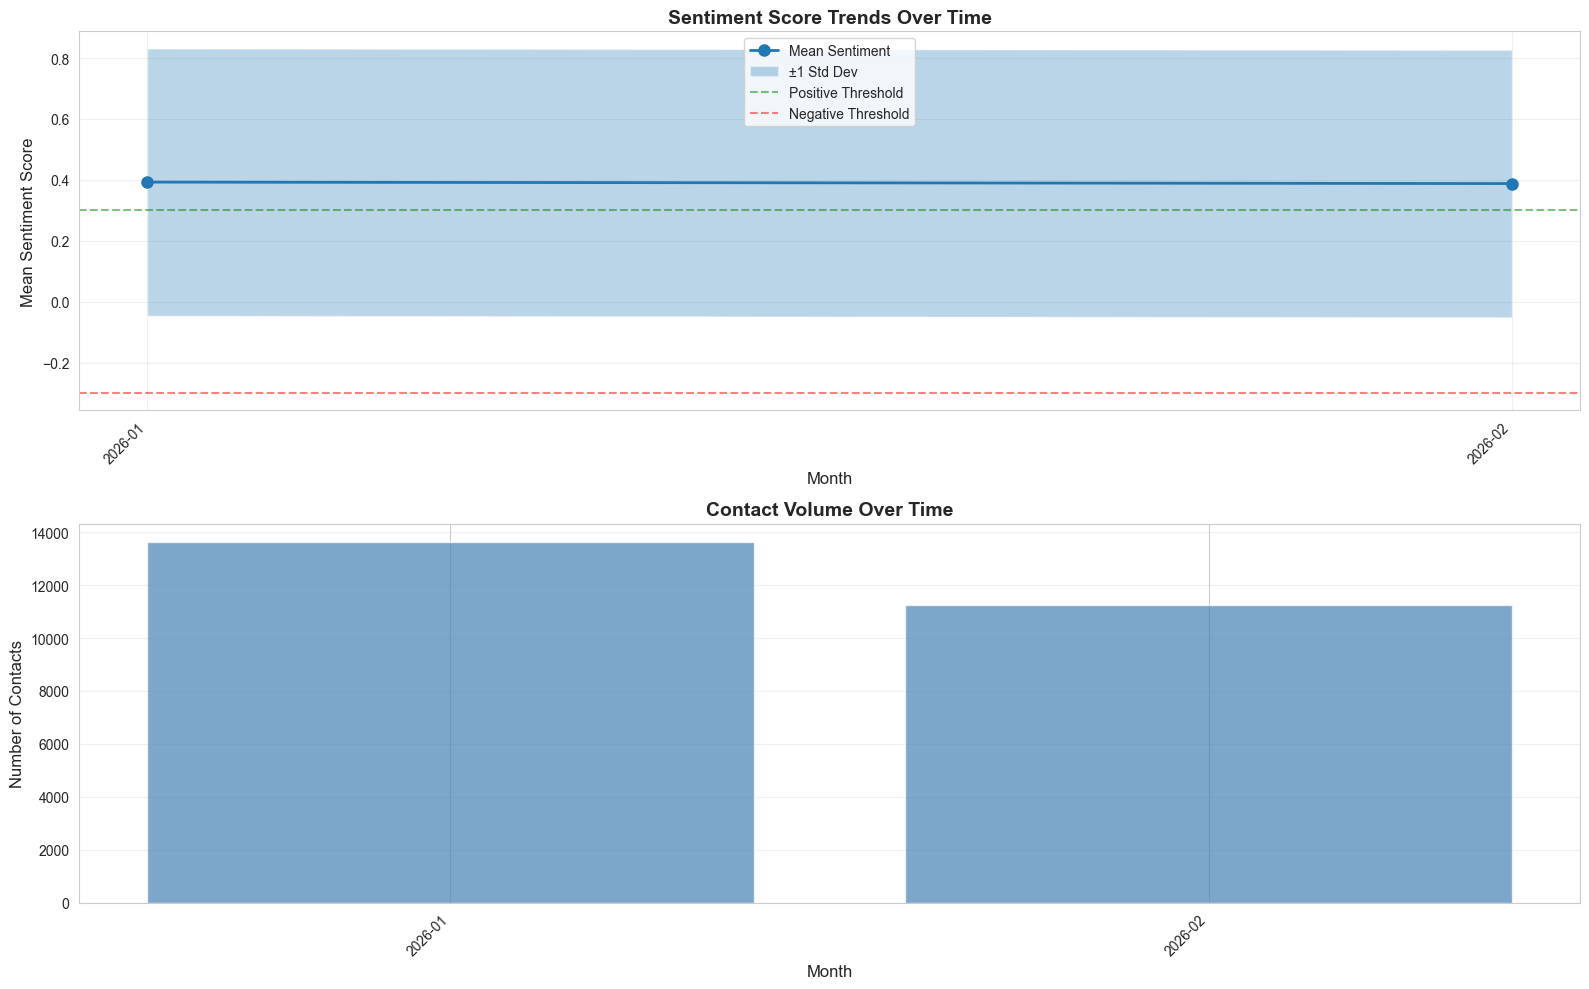


Monthly Sentiment Statistics:
  contact_year_month      mean       std  count
0            2026-01  0.392665  0.438557  13631
1            2026-02  0.387858  0.438719  11243


In [12]:
# Analyze sentiment trends over time
if 'sentiment_score' in df.columns and 'last_contact_date' in df.columns:
    # Convert date column
    df['last_contact_date'] = pd.to_datetime(df['last_contact_date'], errors='coerce')
    
    # Filter valid dates
    df_with_dates = df[df['last_contact_date'].notna()].copy()
    
    if len(df_with_dates) > 0:
        # Create time-based features
        df_with_dates['contact_month'] = df_with_dates['last_contact_date'].dt.to_period('M')
        df_with_dates['contact_year_month'] = df_with_dates['last_contact_date'].dt.strftime('%Y-%m')
        
        # Group by month
        monthly_sentiment = df_with_dates.groupby('contact_year_month')['sentiment_score'].agg(['mean', 'std', 'count']).reset_index()
        monthly_sentiment = monthly_sentiment.sort_values('contact_year_month')
        
        # Plot temporal trends
        fig, axes = plt.subplots(2, 1, figsize=(16, 10))
        
        # Mean sentiment over time
        axes[0].plot(monthly_sentiment['contact_year_month'], monthly_sentiment['mean'], 
                    marker='o', linewidth=2, markersize=8, label='Mean Sentiment')
        axes[0].fill_between(monthly_sentiment['contact_year_month'], 
                            monthly_sentiment['mean'] - monthly_sentiment['std'],
                            monthly_sentiment['mean'] + monthly_sentiment['std'],
                            alpha=0.3, label='±1 Std Dev')
        axes[0].axhline(y=0.3, color='green', linestyle='--', alpha=0.5, label='Positive Threshold')
        axes[0].axhline(y=-0.3, color='red', linestyle='--', alpha=0.5, label='Negative Threshold')
        axes[0].set_ylabel('Mean Sentiment Score', fontsize=12)
        axes[0].set_xlabel('Month', fontsize=12)
        axes[0].set_title('Sentiment Score Trends Over Time', fontsize=14, fontweight='bold')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        axes[0].tick_params(axis='x', rotation=45)
        plt.setp(axes[0].xaxis.get_majorticklabels(), ha='right')
        
        # Count of contacts over time
        axes[1].bar(monthly_sentiment['contact_year_month'], monthly_sentiment['count'], 
                   alpha=0.7, color='steelblue')
        axes[1].set_ylabel('Number of Contacts', fontsize=12)
        axes[1].set_xlabel('Month', fontsize=12)
        axes[1].set_title('Contact Volume Over Time', fontsize=14, fontweight='bold')
        axes[1].tick_params(axis='x', rotation=45)
        plt.setp(axes[1].xaxis.get_majorticklabels(), ha='right')
        axes[1].grid(True, alpha=0.3, axis='y')
        
        plt.tight_layout()
        plt.show()
        
        print("\nMonthly Sentiment Statistics:")
        print(monthly_sentiment.head(10))

In [13]:
# Generate summary insights
print("=" * 80)
print("SENTIMENT ANALYSIS - KEY INSIGHTS")
print("=" * 80)

if 'sentiment_score' in df.columns:
    print(f"\n1. SENTIMENT SCORE STATISTICS:")
    print(f"   - Mean: {df['sentiment_score'].mean():.3f}")
    print(f"   - Median: {df['sentiment_score'].median():.3f}")
    print(f"   - Std Dev: {df['sentiment_score'].std():.3f}")
    print(f"   - Min: {df['sentiment_score'].min():.3f}")
    print(f"   - Max: {df['sentiment_score'].max():.3f}")
    
    # Categorize based on thresholds
    positive_count = (df['sentiment_score'] > 0.3).sum()
    neutral_count = ((df['sentiment_score'] >= -0.3) & (df['sentiment_score'] <= 0.3)).sum()
    negative_count = (df['sentiment_score'] < -0.3).sum()
    
    print(f"\n2. SENTIMENT DISTRIBUTION (Based on Thresholds):")
    print(f"   - Positive (>0.3): {positive_count} ({positive_count/len(df)*100:.2f}%)")
    print(f"   - Neutral (-0.3 to 0.3): {neutral_count} ({neutral_count/len(df)*100:.2f}%)")
    print(f"   - Negative (<-0.3): {negative_count} ({negative_count/len(df)*100:.2f}%)")
    
    if 'health_score' in df.columns:
        corr_health = df[['sentiment_score', 'health_score']].corr().iloc[0, 1]
        print(f"\n3. RELATIONSHIP WITH HEALTH SCORE:")
        print(f"   - Correlation: {corr_health:.3f}")
    
    if 'churn_probability' in df.columns:
        corr_churn = df[['sentiment_score', 'churn_probability']].corr().iloc[0, 1]
        print(f"\n4. RELATIONSHIP WITH CHURN PROBABILITY:")
        print(f"   - Correlation: {corr_churn:.3f}")
    
    print(f"\n5. RECOMMENDATIONS:")
    print(f"   - Use HuggingFace distilbert-base-uncased-finetuned-sst-2-english for text analysis")
    print(f"   - Process text from: emails, support tickets, call transcripts, surveys")
    print(f"   - Map model output to sentiment_score range (-1.0 to 1.0)")
    print(f"   - Update sentiment scores every 24 hours")
    print(f"   - Extract keywords for sentiment indicators")

print("\n" + "=" * 80)
print("EDA COMPLETE - Ready for Model Training")
print("=" * 80)

SENTIMENT ANALYSIS - KEY INSIGHTS

1. SENTIMENT SCORE STATISTICS:
   - Mean: 0.390
   - Median: 0.478
   - Std Dev: 0.439
   - Min: -0.999
   - Max: 1.000

2. SENTIMENT DISTRIBUTION (Based on Thresholds):
   - Positive (>0.3): 15685 (63.06%)
   - Neutral (-0.3 to 0.3): 7540 (30.31%)
   - Negative (<-0.3): 1649 (6.63%)

3. RELATIONSHIP WITH HEALTH SCORE:
   - Correlation: 0.804

4. RELATIONSHIP WITH CHURN PROBABILITY:
   - Correlation: -0.651

5. RECOMMENDATIONS:
   - Use HuggingFace distilbert-base-uncased-finetuned-sst-2-english for text analysis
   - Process text from: emails, support tickets, call transcripts, surveys
   - Map model output to sentiment_score range (-1.0 to 1.0)
   - Update sentiment scores every 24 hours
   - Extract keywords for sentiment indicators

EDA COMPLETE - Ready for Model Training
